In [1]:
import numpy as np
from loadmodules import *
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

%matplotlib inline
rcParams['figure.facecolor'] = 'white'
plt.style.use('petroff10')

In [2]:
level4_dir = './level4/'

simulation = sorted([directory for directory in os.listdir(level4_dir) if 'Au06' in directory and 'cfea_fiducial' in directory])

In [3]:
nbins = 25
min_gcmf = 1e2 # in solar masses
min_icmf = 5e3 # in solar masses
max_gcmf = 1e8 # in solar masses
marray_gcmf = np.linspace(np.log10(min_gcmf), np.log10(max_gcmf), nbins + 1)
marray_icmf = np.linspace(np.log10(min_icmf), np.log10(max_gcmf), nbins + 1)
width = np.diff(marray_gcmf)
marray_plot = 0.5 * (marray_gcmf[:-1] + marray_gcmf[1:])
imarray_plot = 0.5 * (marray_icmf[:-1] + marray_icmf[1:])

In [4]:
m31_masses = np.genfromtxt('catalogues_compare/Caldwell_dataonly.txt', usecols=11, delimiter=',')
Ngcs,_ = np.histogram(m31_masses, bins=marray_gcmf)
m31_mass_function = Ngcs/width

mw_catalogue = np.genfromtxt('catalogues_compare/Harris_onlyphotometry.txt', usecols=(0,6,12), delimiter=',', skip_header=1)
mw_masses = np.log10(1.7 * 10**(0.4*(4.83 - mw_catalogue[:,1])))
Ngcs,_ = np.histogram(mw_masses, bins=marray_gcmf)
mw_mass_function = Ngcs/width

In [8]:
sf = load_subfind(127, dir=level4_dir+simulation[0]+'/output/', hdf5=True, loadonly=['fpos', 'fmc2', 'frc2', 'svel', 'flty', 'fmty', 'fnsh', 'slty', 'spos', 'smty', 'ffsh'] )
s = gadget_readsnap(127, snappath=level4_dir+simulation[0]+'/output/', subfind=sf, hdf5=True, applytransformationfacs=True, loadonlyhalo=0, loadonlytype=[4])
s.calc_sf_indizes( sf )
s.select_halo( sf, use_principal_axis=True, use_cold_gas_spin=False, do_rotation=True )
galrad = sf.data['frc2'][0]
solar_mass_g = 1.989e33
G_cgs = 6.6738e-8 # cm^3 g^-1 s^-2
parsec = 3.08567758e18 # cm

starparts = (s.data['age']>0.) * (s.r()<galrad) * (s.data['subhalo']==0)

Lz = pylab.cross( s.data['pos'], (s.data['vel'] ) )[:,0]
orbital_energy = s.data['pot'] + 0.5 * np.sum(s.data['vel']**2, axis=1)

mask_clusters_final = (s.data['nclt'][starparts] > 0 )

jz = Lz[starparts]
ii = np.argsort(orbital_energy[starparts])
eps = jz[ii]
npm = 50
eps /= [ np.max(eps[:i+npm]) if i < npm else np.max(eps[i-npm:]) if i > size(ii)-npm else np.max(eps[i-npm:i+npm]) for i in range(size(ii)) ]
ilist = np.array(list(range(0, len(eps))))# ilist=1,2,3,4,5
ilist = ilist[ii] # ilist=5,4,3,2,1
resort = np.argsort(ilist) # resort=5,4,3,2,1
eps = eps[resort] # eps2=5,4,3,2,1

# Build feature array: [ε, Energy]
X = np.vstack((eps,orbital_energy[starparts],
                np.log10(np.abs(s.data['pos'][:,0][starparts])))).T

# Fit GMM
gmm = GaussianMixture(n_components=2, means_init=[[0.0,np.median(orbital_energy[starparts]), -2],
                                                    [0.9,np.median(orbital_energy[starparts]), -5]],
                                                    covariance_type='full', random_state=42)
gmm.fit(X)

# Predict cluster memberships
decomp_labels = gmm.predict(X)
median_eps = [np.median(eps[decomp_labels==i]) for i in range(gmm.n_components)]
sph_label = np.argmin(median_eps)
disc_label = np.argmax(median_eps)

# Force assign disc_label to clusters with high circularity parameter
mask = (decomp_labels == sph_label) & (eps > 0.7)# & (s.r()[starparts] < np.percentile(s.r()[starparts][decomp_labels == disc_label], 0.5))
decomp_labels[mask] = disc_label

# Force assign sph_label to clusters with high z-coordinate (5kpc)
mask = (decomp_labels == disc_label) & (np.abs(s.data['pos'][:,0][starparts])*1e3 > 5.)
decomp_labels[mask] = sph_label

mask_spheroid = decomp_labels[mask_clusters_final] == sph_label

cluster_masses = s.data['mclt'][starparts][mask_clusters_final].flatten()
not_empty_clusters = (cluster_masses>0)
cluster_masses = 1e10*cluster_masses[not_empty_clusters]

stars_age = s.cosmology_get_lookback_time_from_a(s.data['age'][starparts][mask_clusters_final], is_flat=True) - s.cosmology_get_lookback_time_from_a(s.time, is_flat=True)
clusters_age = np.repeat(stars_age, s.data['nclt'][starparts][mask_clusters_final])

mask_decomposition = np.repeat(mask_spheroid, s.data['nclt'][starparts][mask_clusters_final])
intemediate_mask = (clusters_age>8.)

Ngcs,_ = np.histogram(np.log10(cluster_masses[mask_decomposition]), bins=marray_gcmf)
spheroid_full_population = Ngcs/width
Ngcs,_ = np.histogram(np.log10(cluster_masses[mask_decomposition*intemediate_mask]), bins=marray_gcmf)
spheroid_old_population = Ngcs/width
Ngcs,_ = np.histogram(np.log10(cluster_masses[~mask_decomposition]), bins=marray_gcmf)
disc_full_population = Ngcs/width
Ngcs,_ = np.histogram(np.log10(cluster_masses[~mask_decomposition*intemediate_mask]), bins=marray_gcmf)
disc_old_population = Ngcs/width

galrad= 0.021391647
Found 1370901 stars.
Rotated pos.
Rotated vel.


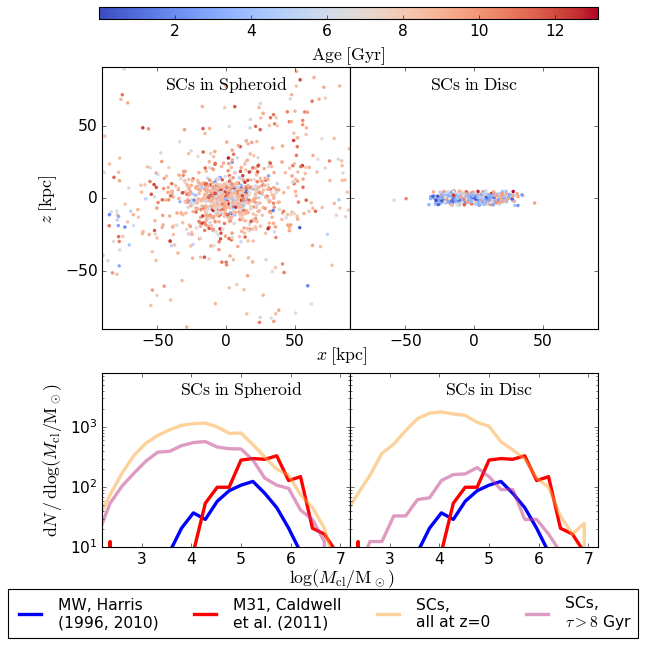

In [13]:
fig, ax = plt.subplots(2, 2, figsize=(8, 7.5), height_ratios=[3,2])

cb = ax[0,0].scatter(1e3*s.data['pos'][s.data['type']==4][starparts][mask_clusters_final][mask_spheroid][:,1],
                     1e3*s.data['pos'][s.data['type']==4][starparts][mask_clusters_final][mask_spheroid][:,0],
                     c=stars_age[mask_spheroid], alpha=1., linewidth=0, s=10, rasterized=True, cmap=cm.coolwarm)
ax[0,0].set_xlim(-90, 90)
ax[0,0].set_ylim(-90, 90)
ax[0,0].text(0, 75, r'$\mathrm{SCs \; in \; Spheroid}$', ha='center', fontsize=16)

ax[0,1].scatter(1e3*s.data['pos'][s.data['type']==4][starparts][mask_clusters_final][~mask_spheroid][:,1],
                1e3*s.data['pos'][s.data['type']==4][starparts][mask_clusters_final][~mask_spheroid][:,0],
                c=stars_age[~mask_spheroid], alpha=1., linewidth=0, s=10, rasterized=True, cmap=cm.coolwarm)
ax[0,1].set_xlim(-90, 90)
ax[0,1].set_ylim(-90, 90)
ax[0,1].set_yticklabels([])
ax[0,1].text(0, 75, r'$\mathrm{SCs \; in \; Disc}$', ha='center', fontsize=16)

ax[0,0].set_ylabel(r'$z \; \rm{[kpc]}$', fontsize=16)
fig.text(0.5, 0.42, r'$x \; \rm{[kpc]}$', fontsize=16, ha='center', va='center')
ax[0,0].tick_params(axis='both', which='both', labelsize=14)
ax[0,1].tick_params(axis='both', which='both', labelsize=14)

cbar = fig.colorbar(cb, cax=fig.add_axes([0.12, 0.98, 0.78, 0.02]), orientation='horizontal')
cbar.set_label(r'$\rm{Age} \; [\rm{Gyr}]$', fontsize=16)
cbar.ax.tick_params(labelsize=14)

colors = plt.cm.plasma(1 - np.linspace(0.2,0.9,3))
for j in range(2):
        ax[1,j].plot(marray_plot, mw_mass_function, linewidth=3, c='b', label='MW, Harris'+'\n'+'(1996, 2010)')
        ax[1,j].plot(marray_plot, m31_mass_function, linewidth=3, c='r', label='M31, Caldwell'+'\n'+'et al. (2011)')
        ax[1,j].tick_params(labelsize=14)
        ax[1,j].set_xlim(2.2,7.2)
        ax[1,j].set(ylim=(1e1,8e3), yscale= 'log')

ax[1,0].text(5, 3.5e3, r'$\mathrm{SCs \; in \; Spheroid}$', ha='center', fontsize=16)
ax[1,1].text(5, 3.5e3, r'$\mathrm{SCs \; in \; Disc}$', ha='center', fontsize=16)
fig.text(0.5, 0.05, r'$\log ( M_{\mathrm{cl}} / \mathrm{M}_\odot )$', fontsize=16, ha='center', va='center')
ax[1,1].set_yticklabels([])
ax[1,0].set_ylabel(r'$\mathrm{d}N \, / \, \mathrm{d} \log (M_{\mathrm{cl}}/\mathrm{M}_\odot)$', fontsize=16)
# All SCs MFs
ax[1,0].plot(marray_plot, spheroid_full_population, linewidth=3, alpha=0.5, c=colors[0], label='SCs,'+'\n'+'all at z=0')
ax[1,0].plot(marray_plot, spheroid_old_population, linewidth=3, alpha=0.5, c=colors[1], label='SCs,'+'\n'+r'$\tau > 8$ Gyr')

# All SCs MFs
ax[1,1].plot(marray_plot, disc_full_population, linewidth=3, alpha=0.5, c=colors[0], label='SCs,'+'\n'+'all at z=0')
ax[1,1].plot(marray_plot, disc_old_population, linewidth=3, alpha=0.5, c=colors[1], label='SCs,'+'\n'+r'$\tau > 8$ Gyr')

handles, labels = [], []
for axis in ax[1,:]:
        h, l = axis.get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)

# Remove duplicate labels
unique = dict(zip(labels, handles))
fig.legend(unique.values(), unique.keys(), loc='center', bbox_to_anchor=(0.47, -.01), ncols=4, fontsize=14, frameon=True)

plt.subplots_adjust(wspace=0.0)
plt.savefig('./plots/position_age_mass_decomp_paper.pdf', bbox_inches='tight')

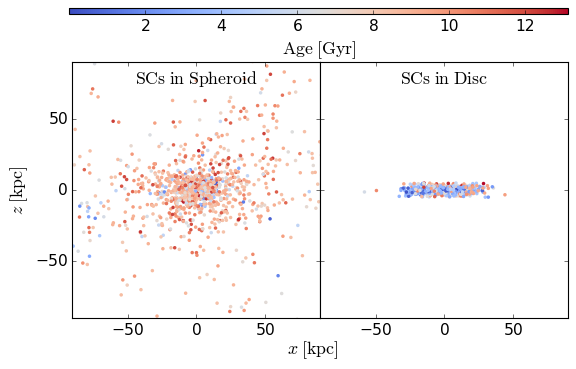

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

cb = ax[0].scatter(1e3*s.data['pos'][s.data['type']==4][starparts][mask_clusters_final][mask_spheroid][:,1],
                     1e3*s.data['pos'][s.data['type']==4][starparts][mask_clusters_final][mask_spheroid][:,0],
                     c=stars_age[mask_spheroid], alpha=1., linewidth=0, s=10, rasterized=True, cmap=cm.coolwarm)
ax[0].set_xlim(-90, 90)
ax[0].set_ylim(-90, 90)
ax[0].text(0, 75, r'$\mathrm{SCs \; in \; Spheroid}$', ha='center', fontsize=16)

ax[1].scatter(1e3*s.data['pos'][s.data['type']==4][starparts][mask_clusters_final][~mask_spheroid][:,1],
                1e3*s.data['pos'][s.data['type']==4][starparts][mask_clusters_final][~mask_spheroid][:,0],
                c=stars_age[~mask_spheroid], alpha=1., linewidth=0, s=10, rasterized=True, cmap=cm.coolwarm)
ax[1].set_xlim(-90, 90)
ax[1].set_ylim(-90, 90)
ax[1].set_yticklabels([])
ax[1].text(0, 75, r'$\mathrm{SCs \; in \; Disc}$', ha='center', fontsize=16)

ax[0].set_ylabel(r'$z \; \rm{[kpc]}$', fontsize=16)
fig.text(0.5, 0., r'$x \; \rm{[kpc]}$', fontsize=16, ha='center', va='center')
ax[0].tick_params(axis='both', which='both', labelsize=14)
ax[1].tick_params(axis='both', which='both', labelsize=14)

cbar = fig.colorbar(cb, cax=fig.add_axes([0.12, 1.05, 0.78, 0.02]), orientation='horizontal')
cbar.set_label(r'$\rm{Age} \; [\rm{Gyr}]$', fontsize=16)
cbar.ax.tick_params(labelsize=14)

plt.subplots_adjust(wspace=0.0)
plt.savefig('./plots/position_age_decomp_paper.pdf', bbox_inches='tight')